<a href="https://colab.research.google.com/github/AadityaBhure/Deep-Learning-Lab---7th-Semester/blob/main/prac8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stock Market Prediction using Recurrent Neural Networks

## Problem Statement
Predict stock price trends using historical NASDAQ stock data and RNN/LSTM models.

## Activities
1.  Prepare sequential data.
2.  Implement LSTM network.
3.  Visualize predicted vs actual values.

## Setup and Data Loading

In [ ]:
#Aaditya Bhure 23070521034

# Install necessary libraries
!pip install yfinance tensorflow scikit-learn matplotlib

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

### Load Historical Stock Data

In [ ]:
# Define the stock ticker and date range
ticker_symbol = '^IXIC'  # NASDAQ Composite Index
start_date = '2010-01-01'
end_date = '2023-01-01'

# Download data
df = yf.download(ticker_symbol, start=start_date, end=end_date)
display(df.head())

/tmp/ipykernel_1483/3876810938.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker_symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^IXIC,^IXIC,^IXIC,^IXIC,^IXIC
Date,,,,,
2010-01-04,2308.419922,2311.149902,2294.409912,2294.409912,1931380000
2010-01-05,2308.709961,2313.729980,2295.620117,2307.270020,2367860000
2010-01-06,2301.090088,2314.070068,2295.679932,2307.709961,2253340000
2010-01-07,2300.050049,2301.300049,2285.219971,2298.090088,2270050000
2010-01-08,2317.169922,2317.600098,2290.610107,2292.239990,2145390000


## Data Preprocessing

In [ ]:
# Use only the 'Close' price for prediction
data = df['Close'].values.reshape(-1, 1)

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Define sequence length
look_back = 60 # Number of previous days to consider for prediction

# Split data into training and testing sets
training_data_len = int(len(scaled_data) * 0.8)
train_data = scaled_data[0:training_data_len, :]
test_data = scaled_data[training_data_len - look_back:, :]

# Function to create sequences
def create_sequences(dataset, look_back):
    X, Y = [], []
    for i in range(look_back, len(dataset)):
        X.append(dataset[i-look_back:i, 0])
        Y.append(dataset[i, 0])
    return np.array(X), np.array(Y)

# Create training sequences
X_train, y_train = create_sequences(train_data, look_back)

# Reshape data for LSTM input (samples, time steps, features)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (2557, 60, 1)
y_train shape: (2557,)


## Model Implementation (LSTM)

In [ ]:
# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(look_back, 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=25))
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
# You might need to adjust epochs and batch_size based on your dataset and computational resources.
model.fit(X_train, y_train, batch_size=32, epochs=25)

Epoch 1/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - loss: 0.0047
Epoch 2/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 5.1398e-04
Epoch 3/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 4.7395e-04
Epoch 4/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 4.3794e-04
Epoch 5/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 3.9584e-04
Epoch 6/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - loss: 3.6293e-04
Epoch 7/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 3.3064e-04
Epoch 8/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 2.9884e-04
Epoch 9/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 2.7590e-04
Epoch 10/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - loss: 2.7501e-04
Epoch 11/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - loss: 2.3617e-04
Epoch 12/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 2.6035e-04
Epoch 13/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 2.6377e-04
Epoch 14/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 2.4201e-04
Epoch 15/25
80/80 ━

## Prediction and Visualization

In [ ]:
# Create testing sequences
X_test, y_test = create_sequences(test_data, look_back)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Make predictions
predictions = model.predict(X_test)

# Inverse transform the predictions and actual values to original scale
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(np.mean(predictions - y_test)**2)
print(f"Root Mean Squared Error: {rmse}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
Root Mean Squared Error: 313.5732556059154


/tmp/ipykernel_1483/3716971399.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


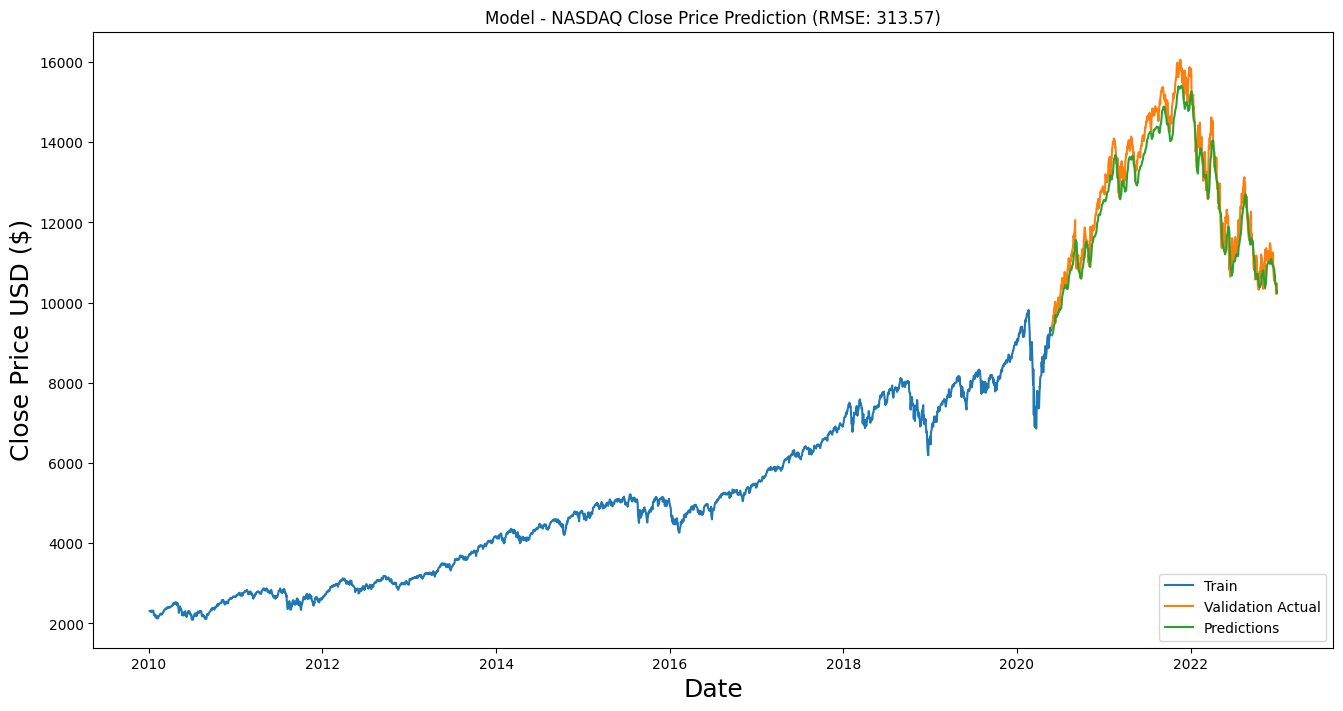

In [ ]:
# Plot the data
train = df[:training_data_len]
valid = df[training_data_len:]
valid['Predictions'] = predictions

# Visualize the data
plt.figure(figsize=(16, 8))
plt.title(f'Model - NASDAQ Close Price Prediction (RMSE: {rmse:.2f})')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Validation Actual', 'Predictions'], loc='lower right')
plt.show()